In [28]:
import os
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from torchvision import models
from PIL import Image

In [29]:
ROOT_DIR = "/home/bmegpu03/Metal_artifact/DATA/240_resize_for_train/dev"
IMG_TYPE = "LAT"
SAVE_PATH = "/home/bmegpu03/Metal_artifact/other_models/ResNet50/Third/model/7"
MODEL_NAME = "LAT.pth"
os.makedirs(SAVE_PATH, exist_ok=True)

#set hyperparameter
# PATIENCE = 10
BATCH_SIZE = 16
EPOCHS = 70
LR = 4.5e-3
WEIGHT_DECAY = 1.0e-4

# Define Model

In [30]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = F.relu(out)

        return out

class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(Bottleneck, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv3 = nn.Conv2d(out_channels, out_channels * self.expansion, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)
        self.downsample = downsample

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = F.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = F.relu(out)

        return out

class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes=1):
        super(ResNet, self).__init__()
        self.in_channels = 64

        self.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_channels != out_channels * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels * block.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * block.expansion),
            )

        layers = []
        layers.append(block(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels * block.expansion

        for _ in range(1, blocks):
            layers.append(block(self.in_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x


def ResNet50(num_classes=1):
    return ResNet(Bottleneck, [3, 4, 6, 3], num_classes=num_classes)

In [31]:
# Early Stopping
class EarlyStopping:
    def __init__(self, patience=10, delta=0.001):
        self.patience = patience
        self.delta = delta
        self.best_loss = None
        self.counter = 0
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

# Dataset

In [32]:
class CustomDataset(Dataset):
    def __init__(self, root_dir, label, img_type):
        self.img_dir = os.path.join(root_dir, str(label), img_type)
        self.img_list = sorted(os.listdir(self.img_dir))  # 파일 정렬
        self.label = label

        self.transform = transforms.Compose([
            transforms.RandomRotation(degrees=(-5, 5)),
            transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
            transforms.RandomApply([transforms.GaussianBlur(3, sigma=(0.1, 1.0))], p=0.5),  # RandNoise
            transforms.ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2)),  # RandGamma
            transforms.Normalize(mean=[0.5], std=[0.5]),
        ])

    def __len__(self):
        return len(self.img_list)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_list[idx])
        image = Image.open(img_path)
        image = np.array(image, dtype=np.float32)
        image = (image - np.min(image)) / (np.max(image) - np.min(image) + 1e-7)  # 0~1 스케일링
        image = torch.tensor(image).unsqueeze(0)  # (C, H, W)
        image = self.transform(image)
        return image, torch.tensor(self.label, dtype=torch.float32).unsqueeze(0)

In [33]:
# Data load and class sampling
def balanced_sampler(label_0_dataset, label_1_dataset, batch_size=16):
    while True:
        indices_0 = random.sample(range(len(label_0_dataset)), batch_size // 2)
        indices_1 = random.sample(range(len(label_1_dataset)), batch_size // 2)
        batch = [label_0_dataset[i] for i in indices_0] + [label_1_dataset[i] for i in indices_1]
        random.shuffle(batch)
        yield [item[0] for item in batch], [item[1] for item in batch]

# Train

In [34]:
train_dataset_0 = CustomDataset(ROOT_DIR, label=0, img_type=IMG_TYPE)
train_dataset_1 = CustomDataset(ROOT_DIR, label=1, img_type=IMG_TYPE)

train_sampler = balanced_sampler(train_dataset_0, train_dataset_1, batch_size=BATCH_SIZE)

In [35]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNet50().to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

best_train_loss = float('inf')
train_loss_list = []
train_acc_list = []

Epoch 1/50, Loss: 0.7648, Accuracy: 50.54%
Best model saved based on training loss!
Epoch 2/50, Loss: 0.7137, Accuracy: 52.17%
Best model saved based on training loss!
Epoch 3/50, Loss: 0.7139, Accuracy: 50.82%
Epoch 4/50, Loss: 0.6973, Accuracy: 52.45%
Best model saved based on training loss!
Epoch 5/50, Loss: 0.6983, Accuracy: 51.45%
Epoch 6/50, Loss: 0.7058, Accuracy: 53.08%
Epoch 7/50, Loss: 0.6937, Accuracy: 53.53%
Best model saved based on training loss!
Epoch 8/50, Loss: 0.6669, Accuracy: 60.05%
Best model saved based on training loss!
Epoch 9/50, Loss: 0.6377, Accuracy: 64.49%
Best model saved based on training loss!
Epoch 10/50, Loss: 0.6584, Accuracy: 62.41%
Epoch 11/50, Loss: 0.5896, Accuracy: 68.12%
Best model saved based on training loss!
Epoch 12/50, Loss: 0.6102, Accuracy: 68.03%
Epoch 13/50, Loss: 0.5400, Accuracy: 72.64%
Best model saved based on training loss!
Epoch 14/50, Loss: 0.5424, Accuracy: 72.83%
Epoch 15/50, Loss: 0.5080, Accuracy: 76.54%
Best model saved base

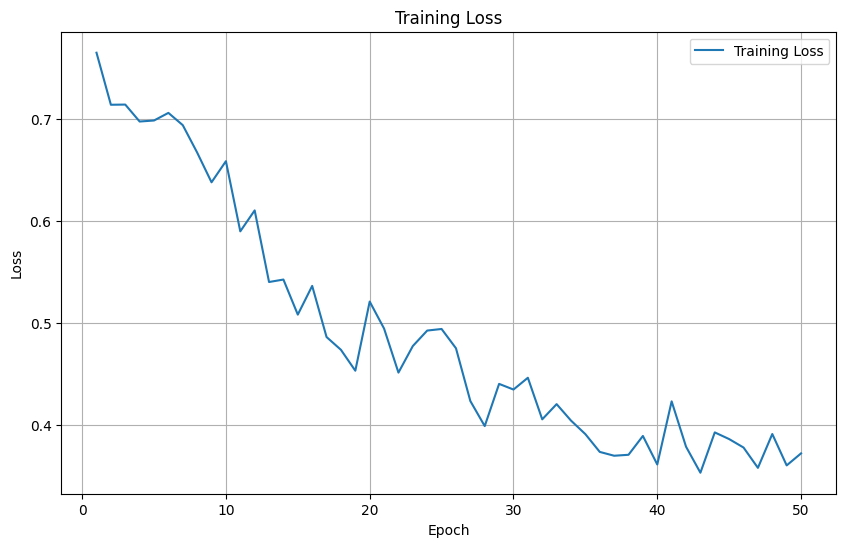

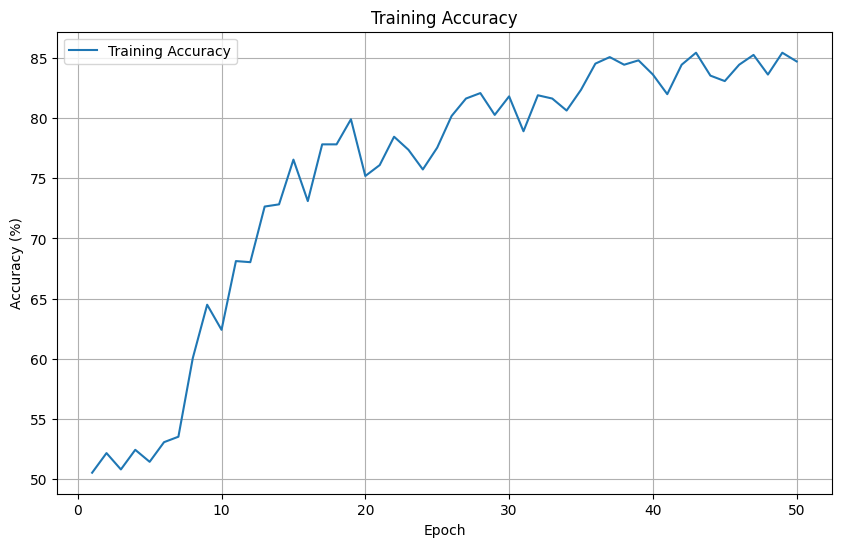

In [36]:
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for _ in range(len(train_dataset_0) // 8):
        inputs, labels = next(train_sampler)
        inputs = torch.stack(inputs).to(device)
        labels = torch.stack(labels).to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = torch.sigmoid(outputs) > 0.5
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / (len(train_dataset_0) // 8)
    epoch_acc = correct / total * 100
    train_loss_list.append(epoch_loss)
    train_acc_list.append(epoch_acc)
    print(f'Epoch {epoch+1}/{EPOCHS}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%')

    if epoch_loss < best_train_loss:
        best_train_loss = epoch_loss
        torch.save(model.state_dict(), os.path.join(SAVE_PATH, MODEL_NAME))
        print('Best model saved based on training loss!')

# Loss 시각화
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_loss_list) + 1), train_loss_list, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.grid(True)
plt.show()

# Accuracy 시각화
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_acc_list) + 1), train_acc_list, label='Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training Accuracy')
plt.legend()
plt.grid(True)
plt.show()